# School Dropout and Educational Performance in Brazil
*Exploring how academic performance, development indicators and resource distribution relate to school dropout patterns.*

**Dataset:** Simulated educational indicators from 10 Brazilian states  
**Techniques:** EDA, correlation analysis, regression modeling, feature importance  
**Tools:** Python, Pandas, Seaborn, Scikit-learn  

**Objective:** Explore which factors are most associated with school dropout and educational outcomes, and show how data analysis can support better decision-making.


## 1. Project Overview

In this project, I explore a question that I find both practical and analytically interesting: **what factors seem to be associated with school dropout?**

School dropout is an important indicator because it reflects both educational performance and broader system conditions. Differences in development levels, access to educational resources and socioeconomic context may all influence how students progress through the education system.

Using a small dataset with state-level indicators from Brazil, I explore how variables such as:

- average ENEM exam scores  
- average income  
- number of public and private schools  
- Human Development Index (HDI)  
- school dropout rates  

The goal of the analysis is to demonstrate how data exploration and modeling can help identify **patterns, risk signals and potential drivers of educational outcomes**.

## 2. Dataset

The dataset contains educational and socioeconomic indicators for 10 Brazilian states.

* `estado`: Brazilian state
* `nota_enem_media`: Average ENEM exam score
* `renda_media_mensal`: Average monthly income
* `escolas_publicas`: Number of public schools
* `escolas_privadas`: Number of private schools
* `idh`: Human Development Index
* `evasao_escolar_percent`: School dropout percentage

This combination of variables makes it possible to explore both **educational performance** and **dropout risk patterns**.

## 3. Data Governance Considerations

Even in small analytical projects, it is important to consider basic principles of data governance.

In real-world scenarios, education datasets often involve sensitive information related to students, institutions and public resources. Responsible data use requires attention to:

- **data quality and reliability**
- **proper documentation of variables**
- **transparency in analytical methods**
- **careful interpretation of results**

Good data governance helps ensure that analyses are not only technically correct, but also trustworthy and useful for decision-making.

In this notebook, the dataset is simplified and anonymized, but the analytical process follows the same principles used in larger data projects.

## 4. Data Preparation

The dataset was created, loaded into a Pandas DataFrame and was checked the structure of the dataset.

After that was checked the variable types, the summary statistics and whether there were missing values.


In [ ]:
import pandas as pd
data = {"estado": ["SP", "RJ", "MG", "RS", "BA", "PE", "CE", "PA", "AM", "DF"],
    "nota_enem_media": [520, 510, 505, 500, 480, 475, 470, 460, 455, 530],
    "renda_media_mensal": [2800, 2600, 2400, 2500, 1800, 1700, 1600, 1500, 1450, 3500],
    "escolas_publicas": [5200, 4300, 4100, 3000, 3800, 3600, 3400, 2900, 2500, 800],
    "escolas_privadas": [2500, 2300, 2200, 2000, 1100, 1050, 950, 900, 850, 1200],
    "idh": [0.83, 0.80, 0.79, 0.78, 0.72, 0.71, 0.70, 0.69, 0.68, 0.87],
    "evasao_escolar_percent": [3.5, 3.8, 4.0, 4.1, 6.2, 6.5, 6.8, 7.0, 7.3, 2.9]}
df = pd.DataFrame(data)

In [ ]:
df.head()

,estado,nota_enem_media,renda_media_mensal,escolas_publicas,escolas_privadas,idh,evasao_escolar_percent
0,SP,520,2800,5200,2500,0.83,3.5
1,RJ,510,2600,4300,2300,0.80,3.8
2,MG,505,2400,4100,2200,0.79,4.0
3,RS,500,2500,3000,2000,0.78,4.1
4,BA,480,1800,3800,1100,0.72,6.2


In [ ]:
df.describe()


,nota_enem_media,renda_media_mensal,escolas_publicas,escolas_privadas,idh,evasao_escolar_percent
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,490.500000,2185.000000,3360.000000,1505.000000,0.757000,5.210000
std,25.975416,679.889697,1188.089035,659.734795,0.065668,1.689477
min,455.000000,1450.000000,800.000000,850.000000,0.680000,2.900000
25%,471.250000,1625.000000,2925.000000,975.000000,0.702500,3.850000
50%,490.000000,2100.000000,3500.000000,1150.000000,0.750000,5.150000
75%,508.750000,2575.000000,4025.000000,2150.000000,0.797500,6.725000
max,530.000000,3500.000000,5200.000000,2500.000000,0.870000,7.300000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   estado                  10 non-null     object 
 1   nota_enem_media         10 non-null     int64  
 2   renda_media_mensal      10 non-null     int64  
 3   escolas_publicas        10 non-null     int64  
 4   escolas_privadas        10 non-null     int64  
 5   idh                     10 non-null     float64
 6   evasao_escolar_percent  10 non-null     float64
dtypes: float64(2), int64(4), object(1)
memory usage: 692.0+ bytes


## 5. Exploratory Data Analysis

I started with a simple exploratory analysis to understand how the main indicators vary across states.

### 5.1. ENEM Performance by State

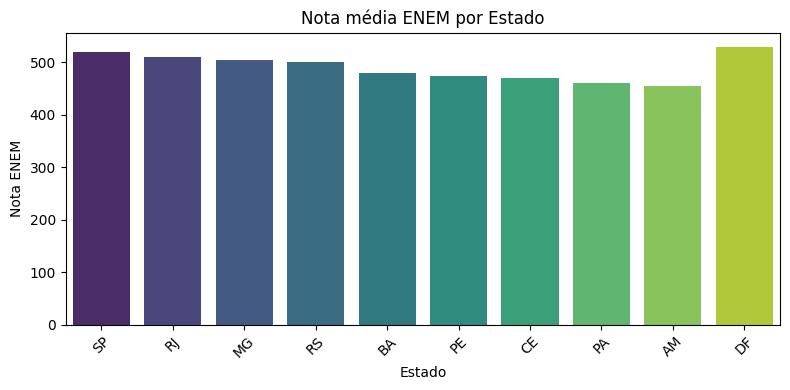

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
sns.barplot(x='estado', y='nota_enem_media', data=df, hue ='estado',palette='viridis')
plt.title('Nota média ENEM por Estado')
plt.ylabel('Nota ENEM')
plt.xlabel('Estado')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The chart shows visible differences in `nota_enem_media` across states. In this dataset, the **Federal District** has the highest score at **530**, while **Amazonas** has the lowest at **455**.

This already suggests that educational outcomes are not evenly distributed.


### 5.2. Average Income by State

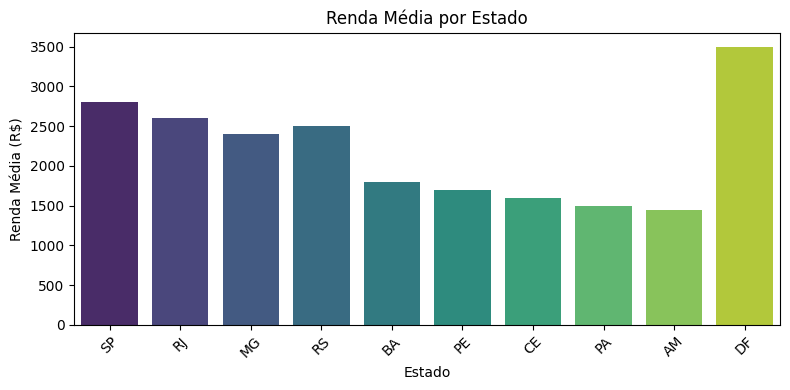

In [ ]:
plt.figure(figsize=(8, 4))
sns.barplot(x='estado', y='renda_media_mensal', data=df, hue='estado', palette='viridis')
plt.title('Renda Média por Estado')
plt.ylabel('Renda Média (R$)')
plt.xlabel('Estado')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Income also varies considerably across states. The highest value in `renda_media_mensal` is **3500**, while the lowest is **1450**.

This matters because income may affect access to resources, school continuity and academic performance.


### 5.3. School Dropout by State

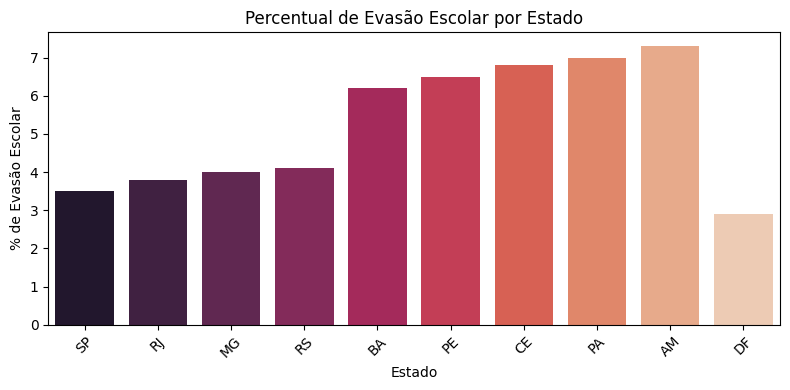

In [ ]:
# Gráfico: Percentual de evasão escolar por estado
plt.figure(figsize=(8, 4))
sns.barplot(x='estado', y='evasao_escolar_percent', data=df, hue='estado', palette='rocket')
plt.title('Percentual de Evasão Escolar por Estado')
plt.ylabel('% de Evasão Escolar')
plt.xlabel('Estado')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Dropout rates in `evasao_escolar_percent` range from **2.9%** to **7.3%** in this sample.

This is a meaningful gap. Even in a small dataset, it suggests that some states may face more retention challenges than others.


## 6. Correlation Analysis

To better understand the relationships between variables, I calculated a correlation matrix using only the numeric columns.


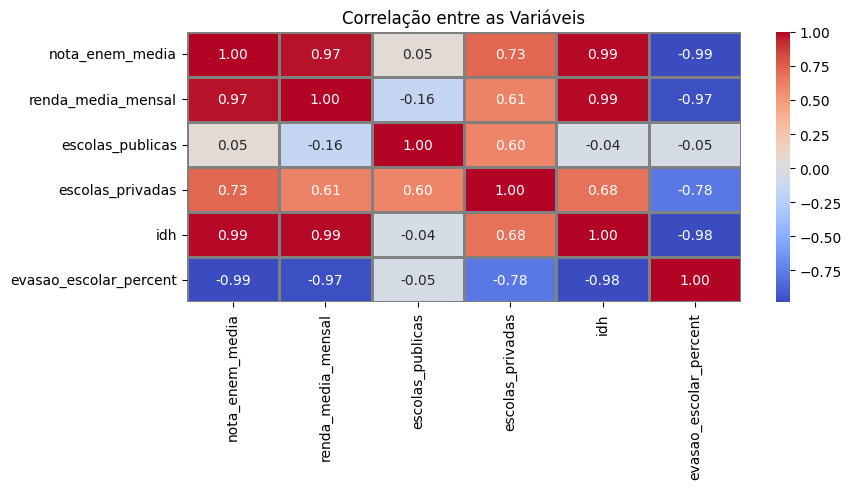

In [ ]:
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(9, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=1, linecolor='gray')
plt.title('Correlação entre as Variáveis')
plt.tight_layout()
plt.show()

A few patterns stand out:

- `renda_media_mensal` appears positively related to `nota_enem_media`
- `idh` appears negatively related to `evasao_escolar_percent`
- stronger development indicators seem to be associated with better outcomes

This type of analysis is useful because it helps identify which variables may deserve more attention in the next steps.


## 7. State Comparison: Highest vs Lowest Income State

To better understand the patterns in the dataset, I compared the states with the highest and lowest values of `renda_media_mensal`.

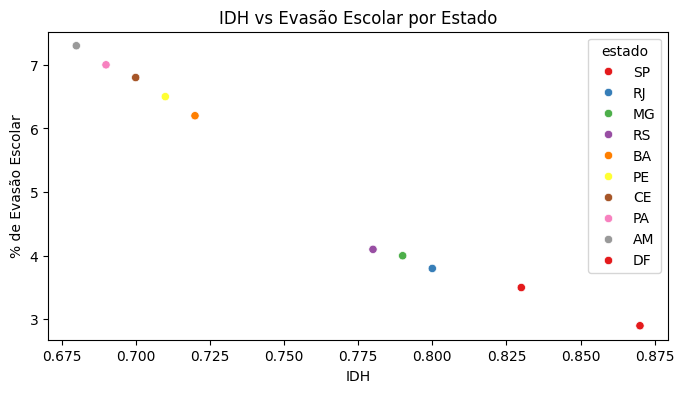

In [ ]:
plt.figure(figsize=(8, 4))
sns.scatterplot(x='idh', y='evasao_escolar_percent', data=df, hue='estado', palette='Set1')
plt.title('IDH vs Evasão Escolar por Estado')
plt.xlabel('IDH')
plt.ylabel('% de Evasão Escolar')
plt.show()

The contrast is clear:

**Federal District** has:
* renda_media_mensal of **3500**
* nota_enem_media of **530**
* evasao_escolar_percent of **2.9**

**Amazonas** has:
* renda_media_mensal of **1450**
* nota_enem_media of **455**  
* evasao_escolar_percent of **7.3**

This contrast suggests that differences in development levels and educational performance may be connected to dropout patterns observed in the dataset.

The comparison does not imply causality, but it helps illustrate how multiple indicators move together.

## 8. Education Risk Index

To make the analysis a little more decision-oriented, I created a simplified **Education Risk Index** combining dropout, development and academic performance.


In [ ]:
df["education_risk_index"] = (df["evasao_escolar_percent"] * 0.5 - df["idh"] * 5 - df["nota_enem_media"] / 200)
df[["estado","education_risk_index"]].sort_values(by="education_risk_index", ascending=False)

,estado,education_risk_index
8,AM,-2.025
7,PA,-2.250
6,CE,-2.450
5,PE,-2.675
4,BA,-2.900
3,RS,-4.350
2,MG,-4.475
1,RJ,-4.650
0,SP,-5.000
9,DF,-5.550


In this ranking, the states with the highest risk scores were:

- **AM**: **-2.025**
- **PA**: **-2.250**
- **CE**: **-2.450**
- **PE**: **-2.675**
- **BA**: **-2.900**

This index is intentionally simple, but it shows one useful idea: instead of looking at just one variable, we can combine signals to highlight where attention may be needed first.


## 9. Predictive Modeling

After the exploratory analysis, I built a simple predictive workflow to estimate `evasao_escolar_percent` from the other variables.

The feature set included:

- `nota_enem_media`
- `renda_media_mensal`
- `escolas_publicas`
- `escolas_privadas`
- `idh`

I tested two regression models:

- Linear Regression
- Decision Tree Regressor

In [ ]:
numeric_cols_mean = df.mean(numeric_only=True)
X = df[['nota_enem_media', 'renda_media_mensal', 'escolas_publicas', 'escolas_privadas', 'idh']]
y = df['evasao_escolar_percent']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train data size: {X_train.shape}")
print(f"Test data size: {X_test.shape}")

Train data size: (8, 5)
Test data size: (2, 5)


### 9.1. Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE Linear Regression: {mse}")
print(f"R² Linear Regression: {r2}")

MSE Linear Regression: 0.00976716231302668
R² Linear Regression: 0.9968107225100321


### 9.2. Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor
model_tree = DecisionTreeRegressor(random_state=42)
model_tree.fit(X_train, y_train)
y_pred_tree = model_tree.predict(X_test)
mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)
print(f"MSE Decision Tree: {mse_tree}")
print(f"R² Decision Tree: {r2_tree}")

MSE Decision Tree: 0.06499999999999999
R² Decision Tree: 0.9787755102040816


Because the dataset has only 10 rows, these numbers should be read with caution. The point here is mainly to demonstrate the workflow, not to claim production-ready performance.


## 10. Model Evaluation

To compare actual and predicted values, I plotted the model outputs against the real dropout values.

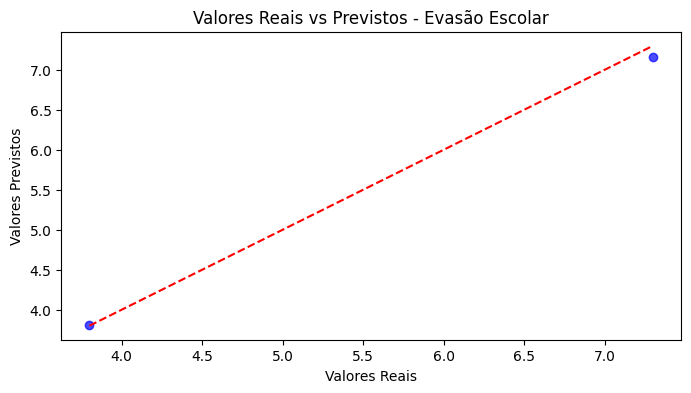

In [ ]:
plt.figure(figsize=(8,4))
plt.scatter(y_test, y_pred, color='blue', alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('Valores Reais vs Previstos - Evasão Escolar')
plt.xlabel('Valores Reais')
plt.ylabel('Valores Previstos')
plt.show()

The model follows the observed values closely in this sample. Again, the small dataset limits the strength of any conclusion, but the step is still useful as part of the analytical process.


## 11. Feature Importance

To add a more data science-oriented layer, I trained a Random Forest model and checked feature importance.


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
importances = rf.feature_importances_
feature_importance = pd.DataFrame({"Feature": X.columns,"Importance": importances}).sort_values(by="Importance", ascending=False)
feature_importance

,Feature,Importance
3,escolas_privadas,0.261867
0,nota_enem_media,0.247240
4,idh,0.222286
1,renda_media_mensal,0.219297
2,escolas_publicas,0.049310


This result suggests that, in this dataset:
* `escolas_privadas`,
* `nota_enem_media`,
* `idh` and
* `renda_media_mensal`

all carry meaningful signal for predicting **evasao_escolar_percent**, while `escolas_publicas` has much lower relative importance. This is useful because it moves the project beyond description and into **variable prioritization**, which is something recruiters often like to see.


## 12. Socioeconomic Drivers of Educational Outcomes

To summarize multiple variables in one view, I created a scatter plot combining income, performance, development and dropout.


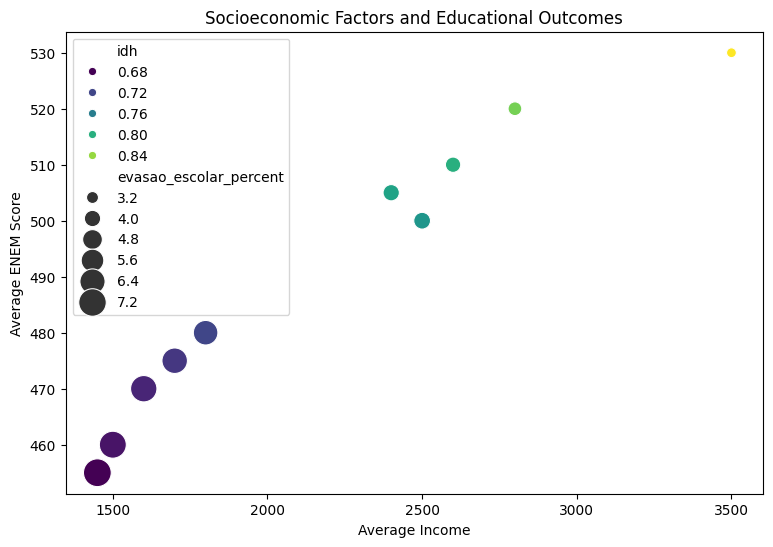

In [ ]:
plt.figure(figsize=(9,6))
sns.scatterplot(x="renda_media_mensal",y="nota_enem_media",size="evasao_escolar_percent",hue="idh",data=df,palette="viridis",sizes=(50,400))
plt.title("Socioeconomic Factors and Educational Outcomes")
plt.xlabel("Average Income")
plt.ylabel("Average ENEM Score")
plt.show()

In this chart:

- the x-axis shows `renda_media_mensal`
- the y-axis shows `nota_enem_media`
- bubble size represents `evasao_escolar_percent`
- color represents `idh`

The pattern is fairly intuitive. States with better socioeconomic conditions tend to appear in the upper-right area of the chart, with **higher ENEM scores** and **smaller dropout bubbles**.


## 13. Key Insights

Even with a simplified dataset, several patterns appear consistently throughout the analysis.

- **nota_enem_media** varies significantly across states, ranging from **455** to **530**
- **evasao_escolar_percent** ranges from **2.9%** to **7.3%**, indicating meaningful differences in dropout patterns
- States with higher **renda_media_mensal** and higher **idh** tend to show stronger educational performance
- The comparison between the Federal District and Amazonas illustrates how differences in development indicators can appear alongside differences in academic outcomes and dropout rates

The feature importance analysis also suggests that several variables contribute to predicting **evasao_escolar_percent**:

- `escolas_privadas`: **0.262**
- `nota_enem_media`: **0.247**
- `idh`: **0.222**
- `renda_media_mensal`: **0.219**
- `escolas_publicas`: **0.049**

Taken together, these results suggest that school dropout patterns are associated with a combination of **academic performance, development indicators and resource distribution**.

While the dataset is intentionally small and simplified, the workflow illustrates how exploratory analysis and predictive modeling can be used to identify possible drivers of educational outcomes.

# Limitations

This project has some important limitations.

- The dataset is small and simplified
- The data is state-level, so it does not capture within-state variation
- The modeling results are illustrative and not suitable for real forecasting
- Other relevant variables such as school funding, teacher quality and attendance were not included

Because of this, the notebook should be read as a **portfolio project and analytical exercise**, not as a definitive study.


# Future Improvements

There are several ways this analysis could be expanded in the future.

- use a larger real-world dataset
- include time series or multi-year analysis
- test additional models
- create a dashboard version for decision-makers
- investigate dropout patterns by region, school type or time period